In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score,learning_curve,validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn import svm,model_selection,preprocessing
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay
)
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
from imblearn.under_sampling import NearMiss
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### Dataset Description 
<li>Jm1 is a dataset created by Nasa to predict software defects</li>
<li>Dataset consists of 22 Attruibutes and 10885 instance</li> 
<li>First 21 attruibutes represents features of the code and last attribute is a boolean value to check if software contain defects or no </li>
<li>21 attruibutes consists of 5  code measures, 3 McCabe metrics, 4 base Halstead measures, 8 derived Halstead measures and a branch-count</li> 

In [166]:
Dataset=pd.read_csv('jm1_csv.csv')
Dataset.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17.0,36.0,112.0,86.0,13.0,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17.0,135.0,329.0,271.0,5.0,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11.0,16.0,76.0,50.0,7.0,True


In [167]:
Dataset.isnull().sum()

loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              5
uniq_Opnd            5
total_Op             5
total_Opnd           5
branchCount          5
defects              0
dtype: int64

In [168]:
Dataset.dtypes

loc                  float64
v(g)                 float64
ev(g)                float64
iv(g)                float64
n                    float64
v                    float64
l                    float64
d                    float64
i                    float64
e                    float64
b                    float64
t                    float64
lOCode                 int64
lOComment              int64
lOBlank                int64
locCodeAndComment      int64
uniq_Op              float64
uniq_Opnd            float64
total_Op             float64
total_Opnd           float64
branchCount          float64
defects                 bool
dtype: object

In [169]:
Dataset['defects']=Dataset['defects'].astype('float')

In [170]:
Dataset.dropna(axis=0,inplace=True)

In [171]:
Dataset.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,0.0
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,1.0
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17.0,36.0,112.0,86.0,13.0,1.0
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17.0,135.0,329.0,271.0,5.0,1.0
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11.0,16.0,76.0,50.0,7.0,1.0


## Data Visualization

In [172]:
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
}
</style>
""")

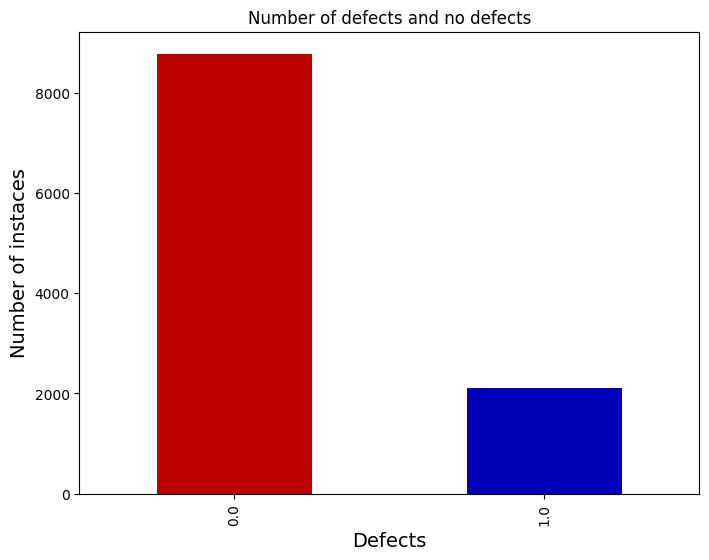

In [173]:
ax=Dataset['defects'].value_counts().plot(kind='bar',color = ['#BB0000', '#0000BB'],
                                          title='Number of defects and no defects',figsize=(8, 6))
ax.set_xlabel("Defects",fontsize=14)
ax.set_ylabel("Number of instaces",fontsize=14)
plt.show()

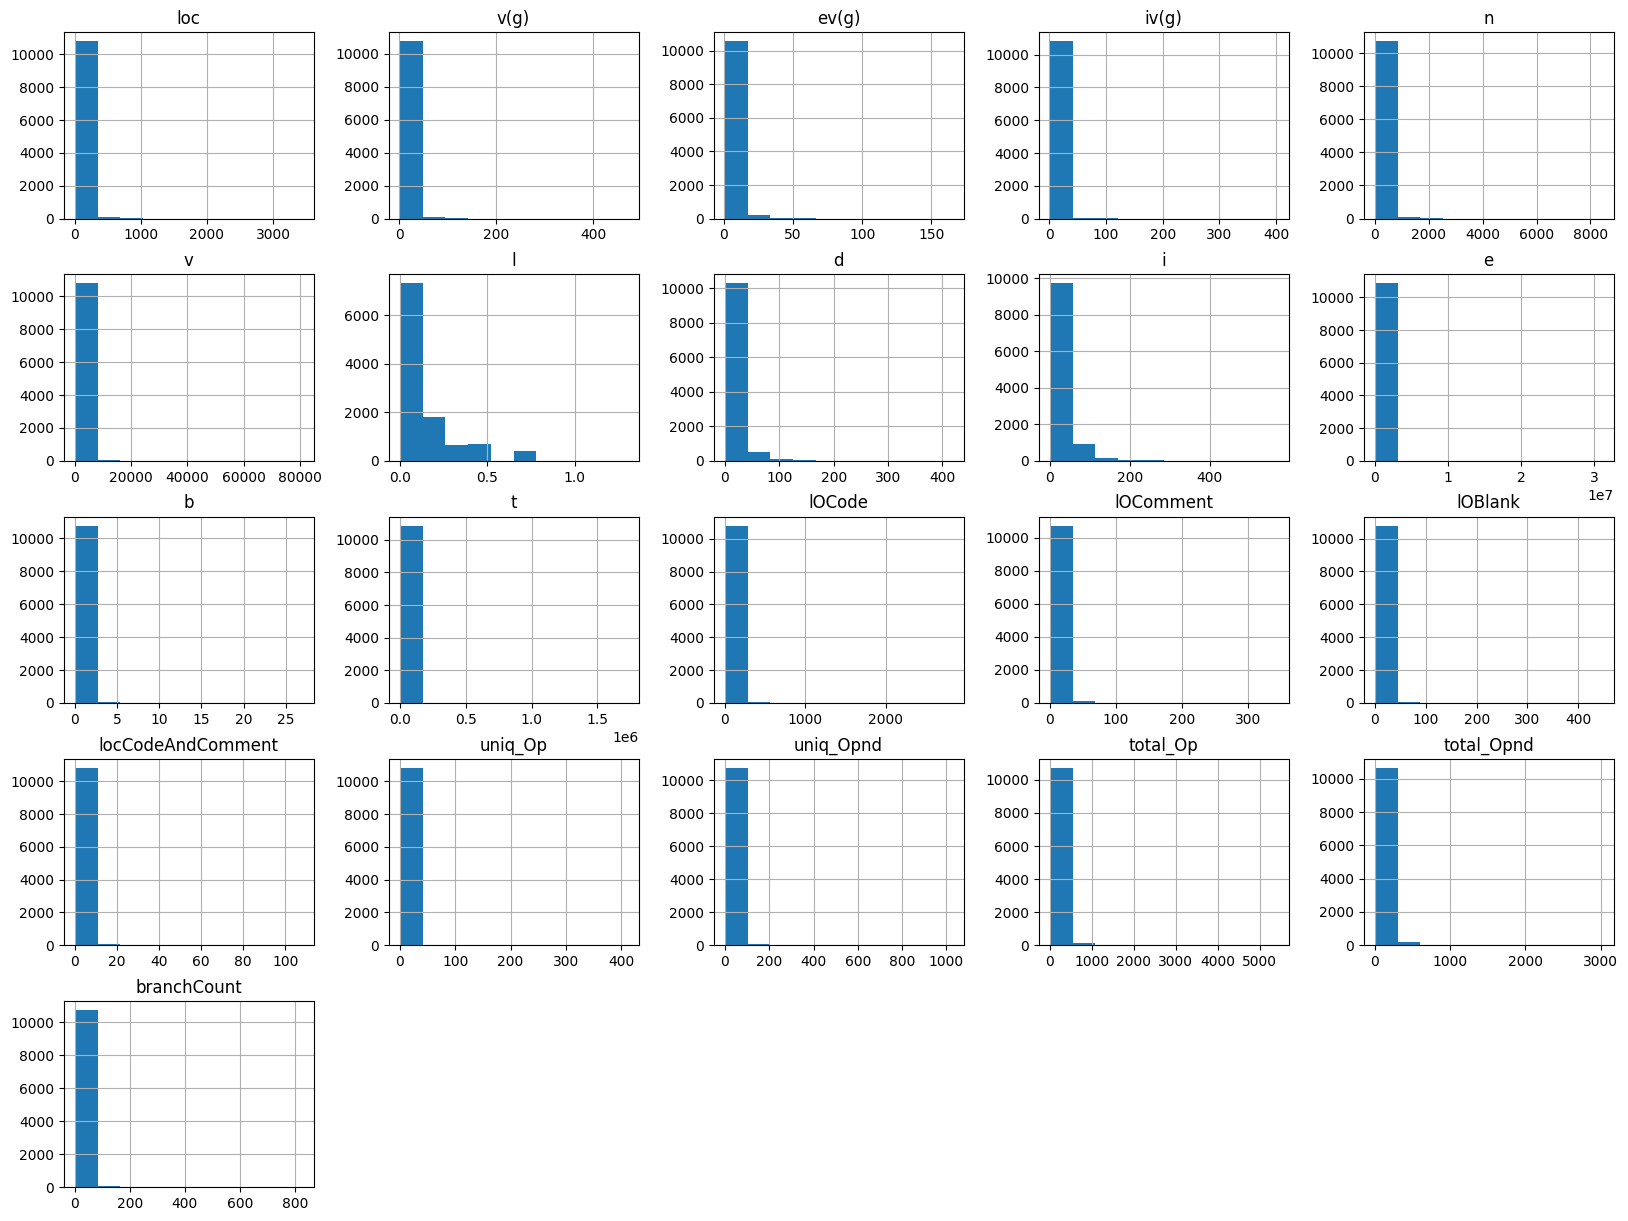

In [174]:
Dataset.iloc[:,:-1].hist(figsize=(20, 15))
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


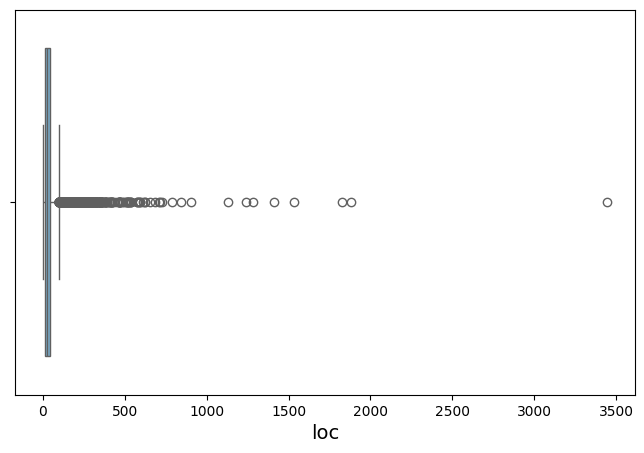

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


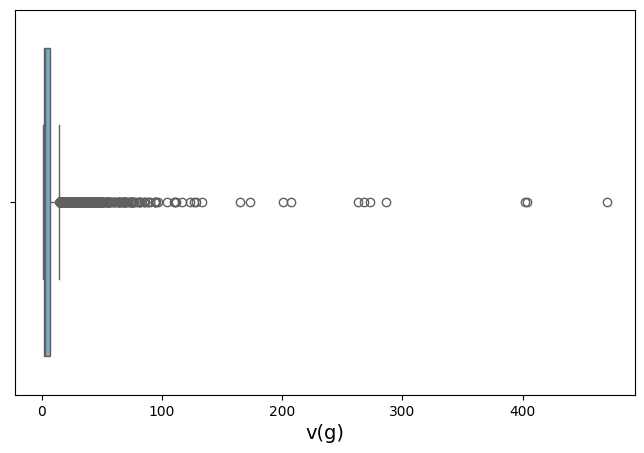

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


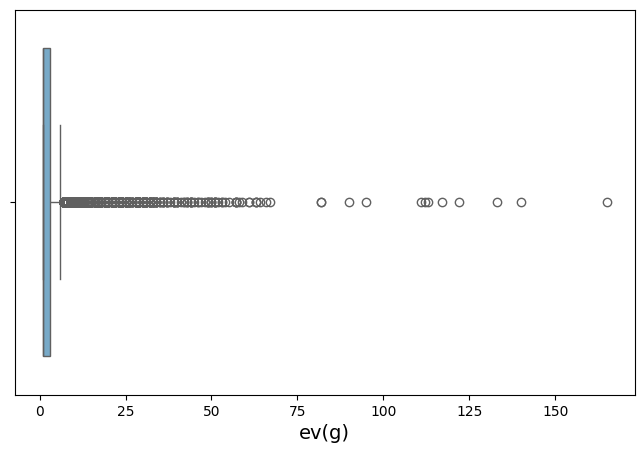

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


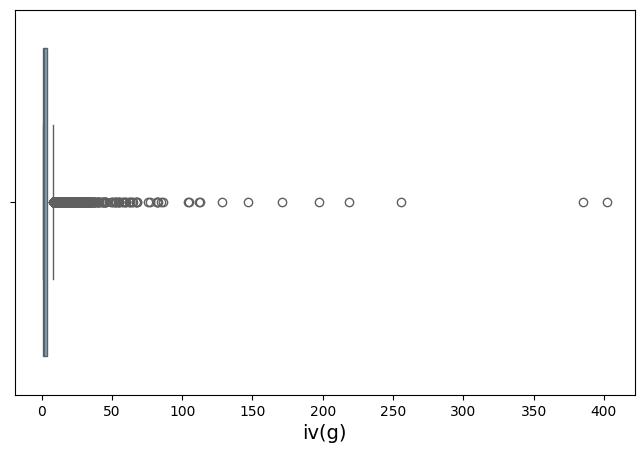

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


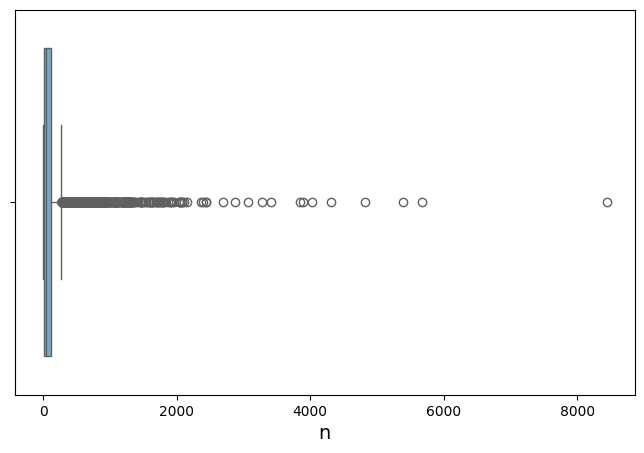

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


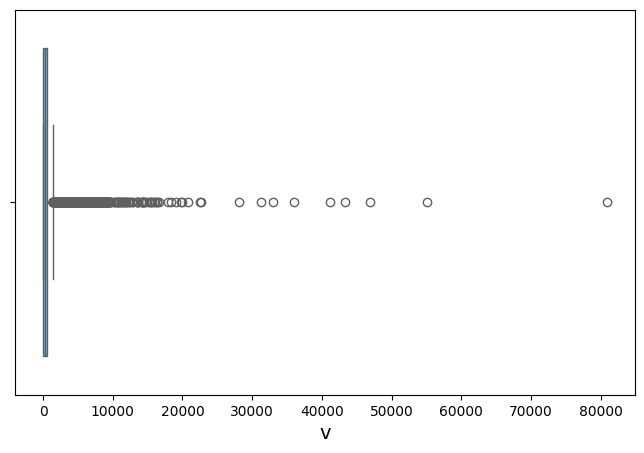

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


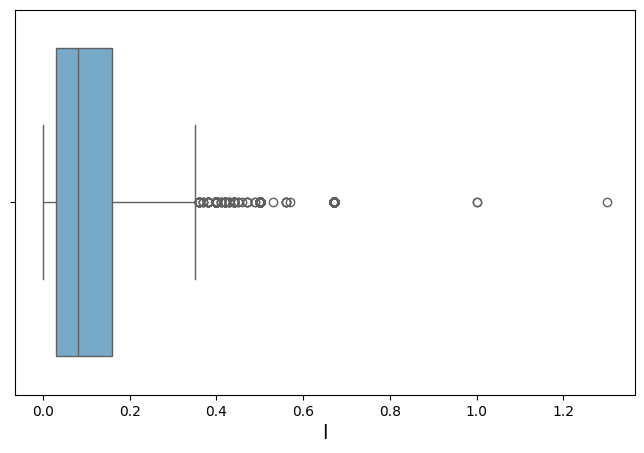

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


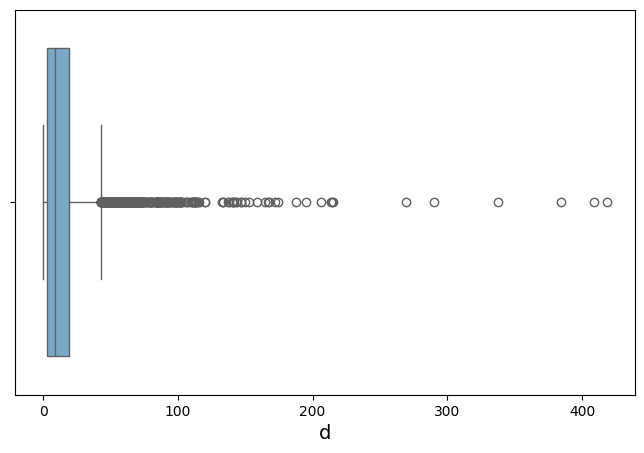

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


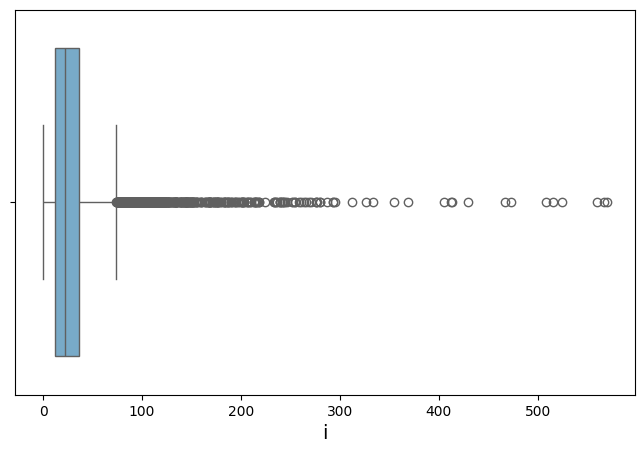

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


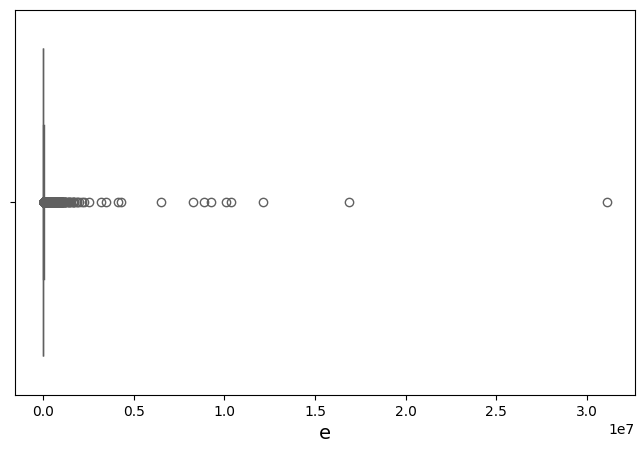

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


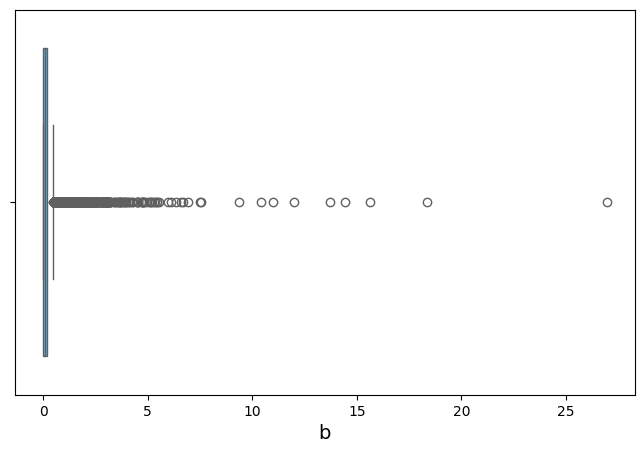

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


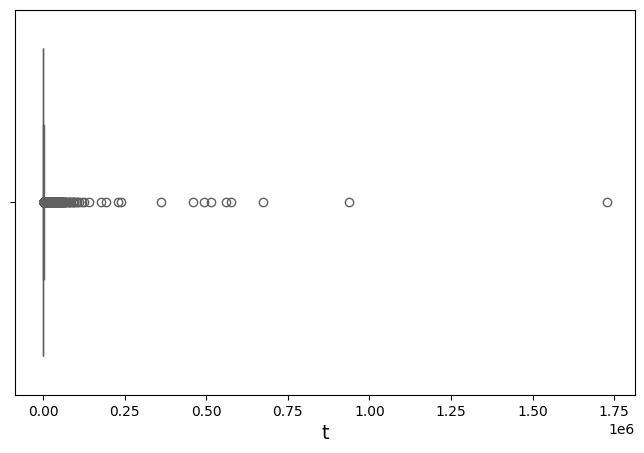

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


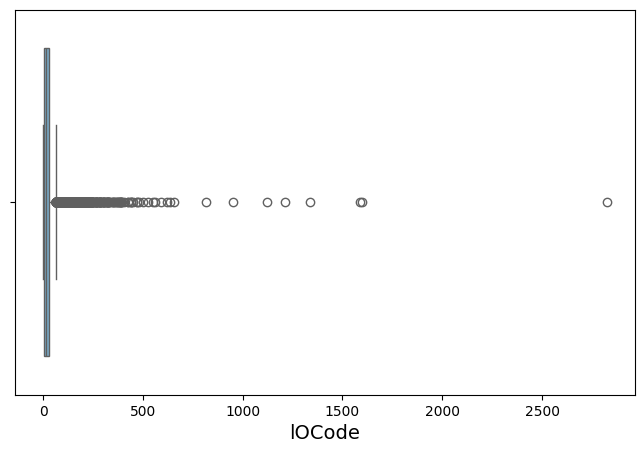

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


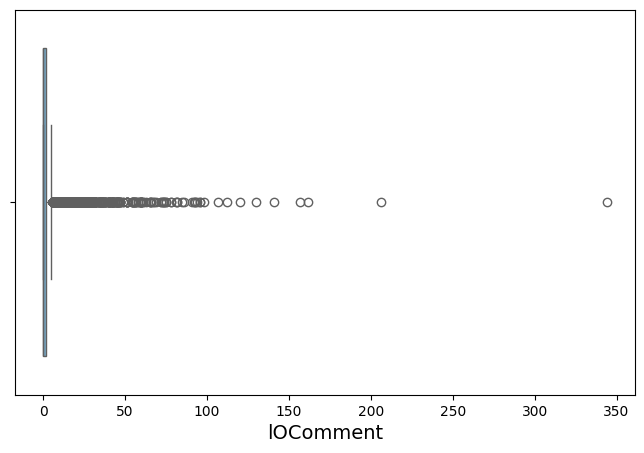

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


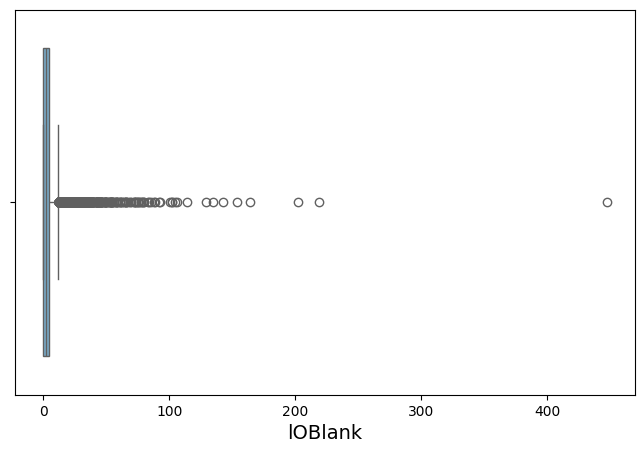

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


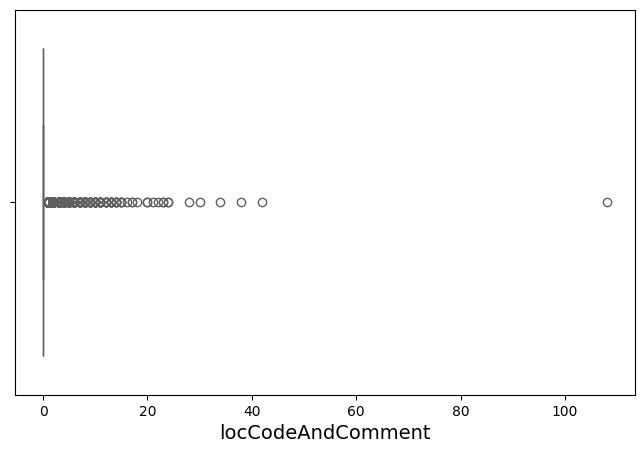

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


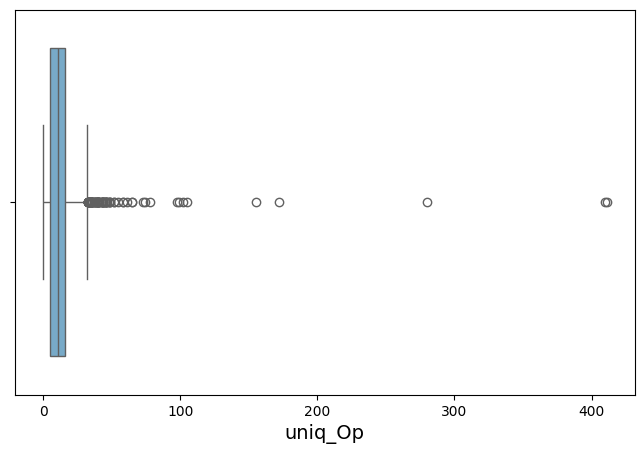

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


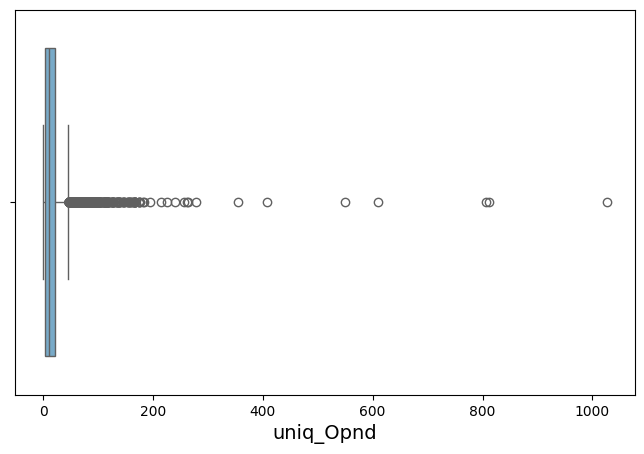

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


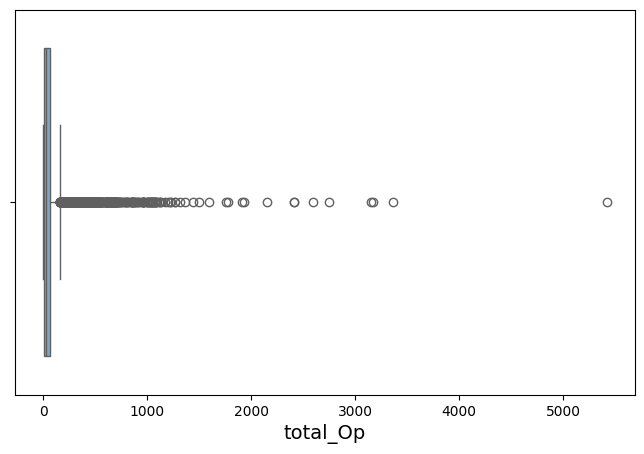

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


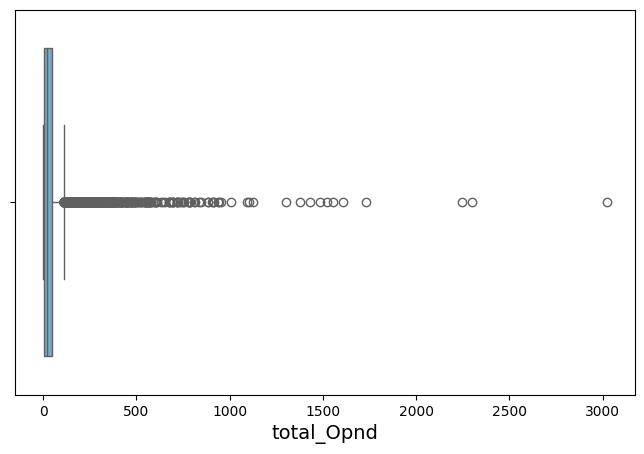

C:\Users\user\AppData\Local\Temp\ipykernel_27900\1253786771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=Dataset[i],palette="Blues")


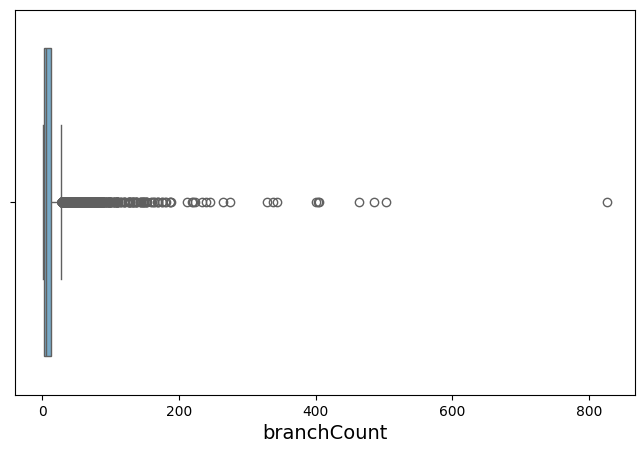

In [175]:
# Plotting box and whisker to ensure of if there are many outliers
for i in Dataset.iloc[:,:-1]:
    plt.figure(figsize=(8,5))
    ax = sns.boxplot(x=Dataset[i],palette="Blues")
    ax.set_xlabel(i,fontsize=14)
    plt.show()

In [176]:
corr = Dataset.corr()
corr 

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
loc,1.000000,0.817795,0.517599,0.784060,0.881790,0.900290,-0.286592,0.689529,0.499926,0.750578,...,0.921915,0.612873,0.803572,0.278119,0.536681,0.764622,0.880967,0.868275,0.830194,0.245437
v(g),0.817795,1.000000,0.701673,0.859591,0.730810,0.759910,-0.252825,0.669091,0.303072,0.709539,...,0.799949,0.384557,0.538381,0.209838,0.647430,0.700514,0.744164,0.696078,0.971958,0.208670
ev(g),0.517599,0.701673,1.000000,0.639572,0.466024,0.445931,-0.233862,0.434036,0.213267,0.315572,...,0.454634,0.294292,0.338253,0.190962,0.263000,0.337031,0.479935,0.435518,0.785553,0.172935
iv(g),0.784060,0.859591,0.639572,1.000000,0.702411,0.743192,-0.197696,0.575354,0.309715,0.757721,...,0.775872,0.351609,0.541284,0.207040,0.500750,0.617966,0.715244,0.668940,0.858994,0.181981
n,0.881790,0.730810,0.466024,0.702411,1.000000,0.984277,-0.240736,0.808101,0.651189,0.716556,...,0.944380,0.596409,0.798548,0.284404,0.610412,0.836171,0.995689,0.989484,0.747894,0.204087
v,0.900290,0.759910,0.445931,0.743192,0.984277,1.000000,-0.198092,0.752202,0.598730,0.800013,...,0.962077,0.576869,0.792323,0.266544,0.606993,0.852296,0.981565,0.971960,0.759971,0.189113
l,-0.286592,-0.252825,-0.233862,-0.197696,-0.240736,-0.198092,1.000000,-0.347213,-0.166792,-0.062034,...,-0.218360,-0.165945,-0.223636,-0.106154,-0.305331,-0.234892,-0.237325,-0.241023,-0.279126,-0.164721
d,0.689529,0.669091,0.434036,0.575354,0.808101,0.752202,-0.347213,1.000000,0.398085,0.574341,...,0.768175,0.502181,0.637171,0.253819,0.749305,0.639686,0.817546,0.777732,0.671976,0.169442
i,0.499926,0.303072,0.213267,0.309715,0.651189,0.598730,-0.166792,0.398085,1.000000,0.209277,...,0.563897,0.392598,0.572311,0.217834,0.391646,0.726696,0.620676,0.687891,0.325796,0.192643
e,0.750578,0.709539,0.315572,0.757721,0.716556,0.800013,-0.062034,0.574341,0.209277,1.000000,...,0.809090,0.384808,0.600673,0.148690,0.482061,0.586805,0.735802,0.673490,0.667886,0.086092


## Preprocessing

In [177]:
# Divide the dataset to x and y 
x_Dataset=Dataset.iloc[:,:-1]
y_Dataset=Dataset.iloc[:,-1]

In [178]:
# Spilting the data into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x_Dataset, y_Dataset, test_size=0.2,random_state=42)
print(x_train.shape, x_test.shape)

(8704, 21) (2176, 21)


In [179]:
# Standarzing the data
sc= StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

#  ML Models 

##  Remove Outliers

In [180]:
# Making a copy of the dataset
datasetWithNoOutliers=Dataset.copy()

In [181]:
# Using IQR method to remove outliers
datasetWithNoOutliers['outlier']=False
# Selecting the most 5 important features in dataset
for col in ['branchCount','uniq_Opnd','total_Op','total_Opnd']:
    q3=Dataset[col].quantile(.75)
    q1=Dataset[col].quantile(.25)
    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    datasetWithNoOutliers.loc[datasetWithNoOutliers[col]>upper,'outlier']= True
    datasetWithNoOutliers.loc[datasetWithNoOutliers[col]<lower,'outlier']= True

In [182]:
#Then selecting outliers and drop rows
datasetWithNoOutliers=datasetWithNoOutliers[datasetWithNoOutliers['outlier'] == False]
datasetWithNoOutliers.drop(['outlier'],axis=1,inplace=True)
len(datasetWithNoOutliers)

9386

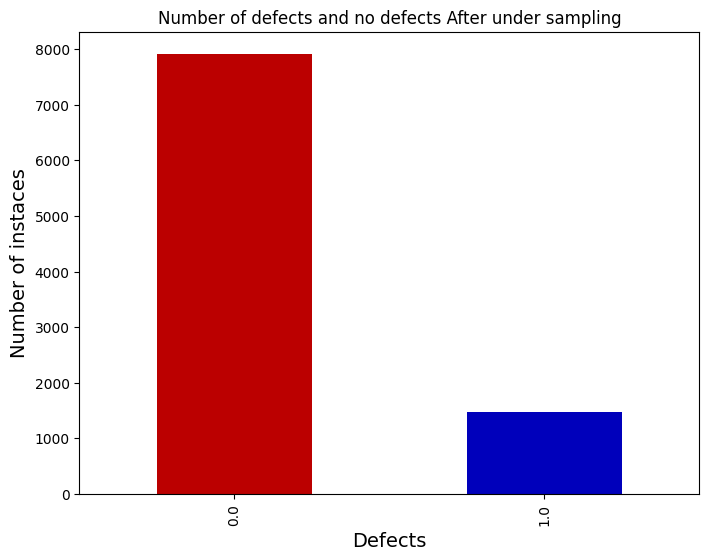

In [183]:
# Drawing number of instances of each class
ax=datasetWithNoOutliers['defects'].value_counts().plot(kind='bar',color = ['#BB0000', '#0000BB'],
                                          title='Number of defects and no defects After under sampling',figsize=(8, 6))
ax.set_xlabel("Defects",fontsize=14)
ax.set_ylabel("Number of instaces",fontsize=14)
plt.show()

In [184]:
#Standarze it again
x_Dataset=datasetWithNoOutliers.iloc[:,:-1]
y_Dataset=datasetWithNoOutliers['defects']
x_train, x_test, y_train, y_test = train_test_split(x_Dataset, y_Dataset, test_size=0.2,random_state=42)
sc= StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Under Sampling

In [185]:
# Make a copy of the dataset
newDS=Dataset.copy()
x_Dataset=Dataset.iloc[:,:-1]
y_Dataset=Dataset['defects']

In [186]:
# Use NearMiss method to undersampling the data
sampler = NearMiss(version=1,sampling_strategy={0: 3000,1: 2103})
x_DS, y_DS = sampler.fit_resample(x_Dataset, y_Dataset)

In [187]:
# splite the new data and scale the features
x_train, x_test, y_train, y_test = train_test_split(x_DS,y_DS, test_size=0.2,random_state=42)
sc= StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

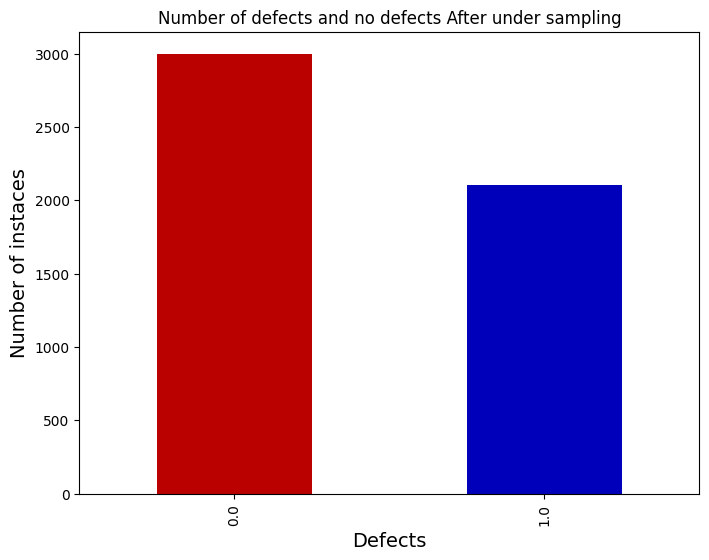

In [189]:
# Now the two classes are balanced 
ax=y_DS.value_counts().plot(kind='bar',color = ['#BB0000', '#0000BB'],
                                          title='Number of defects and no defects After under sampling',figsize=(8, 6))
ax.set_xlabel("Defects",fontsize=14)
ax.set_ylabel("Number of instaces",fontsize=14)
plt.show()

## Our Evalution Function

In [204]:
import numpy as np
import pandas as pd
from sklearn import model_selection
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score
)

def evaluate_model(name, model, x_train, y_train, x_test, y_test):
    
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Cross-validation
    kfold = model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
    cv_acc = cross_val_score(model, x_train, y_train, cv=kfold).mean()

    # Precision / Recall / F1 (macro)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro'
    )

    # Confusion matrix + per-class accuracy
    cm = confusion_matrix(y_test, y_pred)
    class0_acc = cm[0,0] / cm[0].sum()
    class1_acc = cm[1,1] / cm[1].sum()
    # ROC-AUC
    roc_auc = roc_auc_score(y_test, y_proba)

    return {
        "Model": name,
        "Accuracy": acc,
        "CV Accuracy": cv_acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "Class 0 Acc": class0_acc,
        "Class 1 Acc": class1_acc
    }

## Random Forest Model

In [191]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report


param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='f1_macro', 
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(x_train, y_train)

best_rf = grid_rf.best_estimator_

print("Best RF Parameters:")
print(grid_rf.best_params_)

print("Best RF CV F1 Score:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best RF Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best RF CV F1 Score:
0.8754409142479689


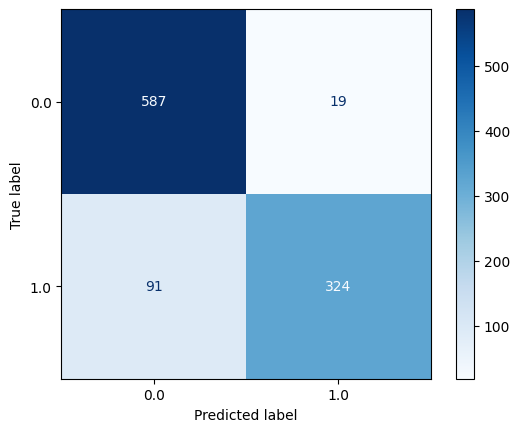

In [208]:
y_pred = best_rf.predict(x_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

## Decision Tree Model

In [192]:
from sklearn.tree import DecisionTreeClassifier

param_grid_tree = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_tree.fit(x_train, y_train)

best_tree = grid_tree.best_estimator_

print("Best Tree Params:", grid_tree.best_params_)
print("Best CV F1:", grid_tree.best_score_)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Tree Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV F1: 0.8636123738674859


## SVM Model

In [193]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

param_grid_svm = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'kernel': ['rbf'],
        'C': [0.01, 0.1, 1, 10, 100],
        'gamma': ['scale', 'auto',0.001, 0.01, 0.1, 1]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(x_train, y_train)

best_svm = grid_svm.best_estimator_

print("Best SVM Params:", grid_svm.best_params_)
print("Best CV F1:", grid_svm.best_score_)


Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best SVM Params: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best CV F1: 0.871022434849811


## KNN Model

In [195]:
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(x_train, y_train)

best_knn = grid_knn.best_estimator_

print("Best KNN Params:", grid_knn.best_params_)
print("Best CV F1:", grid_knn.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best KNN Params: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
Best CV F1: 0.8657042830330104


## XGBoost Model

In [196]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid_xgb,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(x_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best XGB Params:", grid_xgb.best_params_)
print("Best CV F1:", grid_xgb.best_score_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best XGB Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV F1: 0.8729980694608062


## Making the Evaluation of Our Models

In [205]:
results = []

results.append(evaluate_model("XGBoost", best_xgb, x_train, y_train, x_test, y_test))
results.append(evaluate_model("Random Forest", best_rf, x_train, y_train, x_test, y_test))
results.append(evaluate_model("SVM", best_svm, x_train, y_train, x_test, y_test))
results.append(evaluate_model("KNN", best_knn, x_train, y_train, x_test, y_test))
results.append(evaluate_model("Decision Tree", best_tree, x_train, y_train, x_test, y_test))

In [206]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-score", ascending=False)

results_df

,Model,Accuracy,CV Accuracy,Precision,Recall,F1-score,ROC-AUC,Class 0 Acc,Class 1 Acc
1,Random Forest,0.892262,0.881185,0.905194,0.874685,0.884606,0.938033,0.968647,0.780723
0,XGBoost,0.891283,0.876777,0.904476,0.873480,0.883494,0.937886,0.968647,0.778313
2,SVM,0.888345,0.878247,0.901557,0.870245,0.880280,0.908712,0.966997,0.773494
4,Decision Tree,0.887365,0.869671,0.899338,0.869800,0.879426,0.923609,0.963696,0.775904
3,KNN,0.880509,0.869670,0.889945,0.863645,0.872426,0.925518,0.953795,0.773494


In [207]:
results_df.style.background_gradient(cmap="Blues")

,Model,Accuracy,CV Accuracy,Precision,Recall,F1-score,ROC-AUC,Class 0 Acc,Class 1 Acc
1,Random Forest,0.892262,0.881185,0.905194,0.874685,0.884606,0.938033,0.968647,0.780723
0,XGBoost,0.891283,0.876777,0.904476,0.873480,0.883494,0.937886,0.968647,0.778313
2,SVM,0.888345,0.878247,0.901557,0.870245,0.880280,0.908712,0.966997,0.773494
4,Decision Tree,0.887365,0.869671,0.899338,0.869800,0.879426,0.923609,0.963696,0.775904
3,KNN,0.880509,0.869670,0.889945,0.863645,0.872426,0.925518,0.953795,0.773494
